In [1]:
import yaml
import pickle as pkl
import matplotlib.pyplot as plt

import torch

from train_utils import utils
from dataset_utils.synthetic_utils import plot_trajectories

/projectnb/biochemai/Grant/interaction_rule_GNN/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


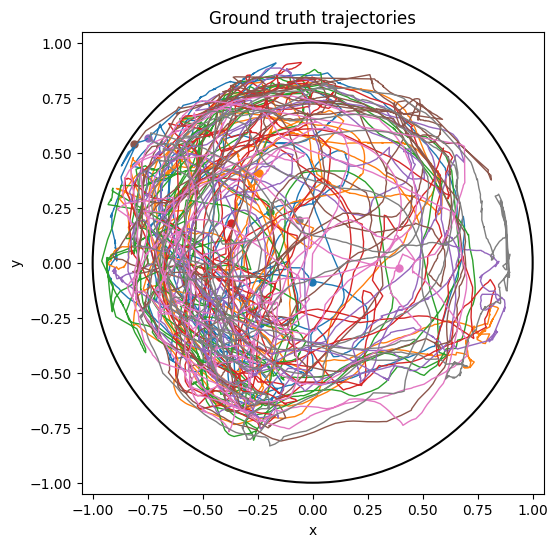

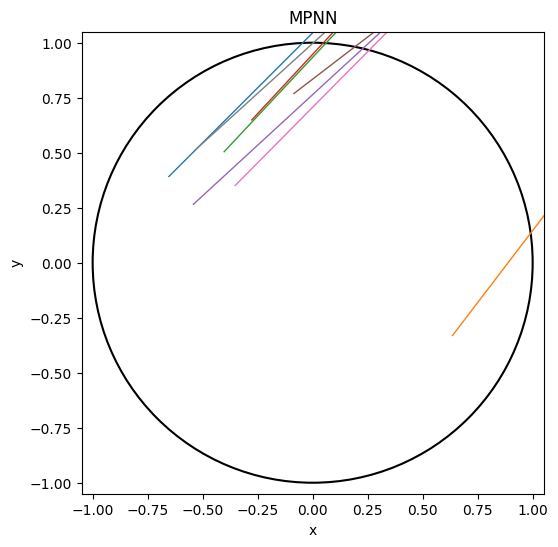

In [2]:
# get the predictions and the ground truth
ground_truth = pkl.load(open('../data/fish/processed/8fish/240816f1.pkl', 'rb'))

# split data up into train
config = yaml.safe_load(open('../_model_comparrison_fish/results/model/mpnn/240816f1_config.yaml', 'r'))
dat_train, dat_val, dat_test = utils.split_with_config(ground_truth, config)

# plotting ground truth
gt_pos = torch.stack([i.pos for i in dat_test])
ax = plot_trajectories(gt_pos.permute(2, 1, 0))
ax.set_title('Ground truth trajectories')

# Plotting predictions
preds = pkl.load(open('../_model_comparrison_fish/results/model/mpnn/240816f1_rollout_preds.pkl', 'rb'))
ax = plot_trajectories(torch.stack(preds).permute(2, 1, 0))
ax.set_title("MPNN")

# preds = pkl.load(open('../_dt_sweep_experiment/results/model/dt128/trial_0_rollout_preds.pkl', 'rb'))
# ax = plot_trajectories(torch.stack(preds).permute(2, 1, 0))
# ax.set_title("128dt")

plt.show()

In [4]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

tb_fp = '../_dt_sweep_experiment/results/logs'

# plotting rollout loss over time for different models
data = {
    'time_step': [],
    'rollout_loss': [],
    'one_step_loss': []
}

# loop through tensorboard events and pull out important data
for time_step in os.listdir(tb_fp):
    for split in os.listdir(os.path.join(tb_fp, time_step)):
        for event in os.listdir(os.path.join(tb_fp, time_step, split)):
            event_acc = EventAccumulator(os.path.join(tb_fp, time_step, split, event))
            event_acc.Reload()
            print(time_step)
            rollout_loss = event_acc.Scalars('test/rollout_loss')
            one_step_loss = event_acc.Scalars('test/loss')[0].value
            data['time_step'].append(time_step)
            data['one_step_loss'].append(one_step_loss)
            data['rollout_loss'].append([(i.value, i.step) for i in rollout_loss])

dt8
dt4
dt167
dt32
dt1024
dt256
dt512
dt1
dt128
dt2
dt16
dt64


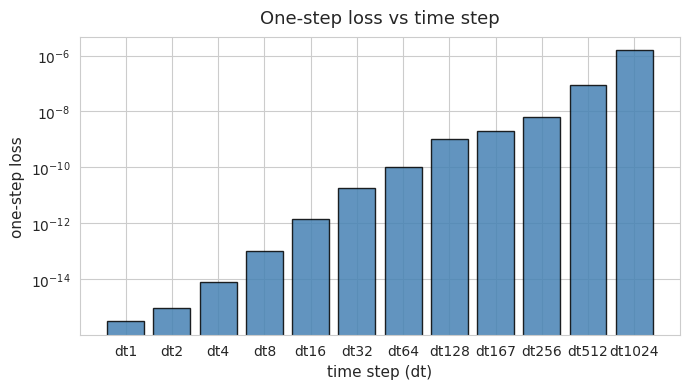

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

time_steps = data['time_step']        # e.g. ['dt8','dt4','dt32',...]
losses     = data['one_step_loss']

# ---- make numeric dt's and sort ----
dt_num = [int(s.replace('dt', '')) for s in time_steps]
order = np.argsort(dt_num)            # indices that sort dt_num

time_steps_sorted = [time_steps[i] for i in order]
losses_sorted     = [losses[i] for i in order]

# ---- nicer plot ----
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(time_steps_sorted, losses_sorted,
       color="steelblue", edgecolor="black", alpha=0.85)

ax.set_yscale("log")
ax.set_xlabel("time step (dt)", fontsize=11)
ax.set_ylabel("one-step loss", fontsize=11)
ax.set_title("One-step loss vs time step", fontsize=13, pad=10)

# ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()

plt.show()

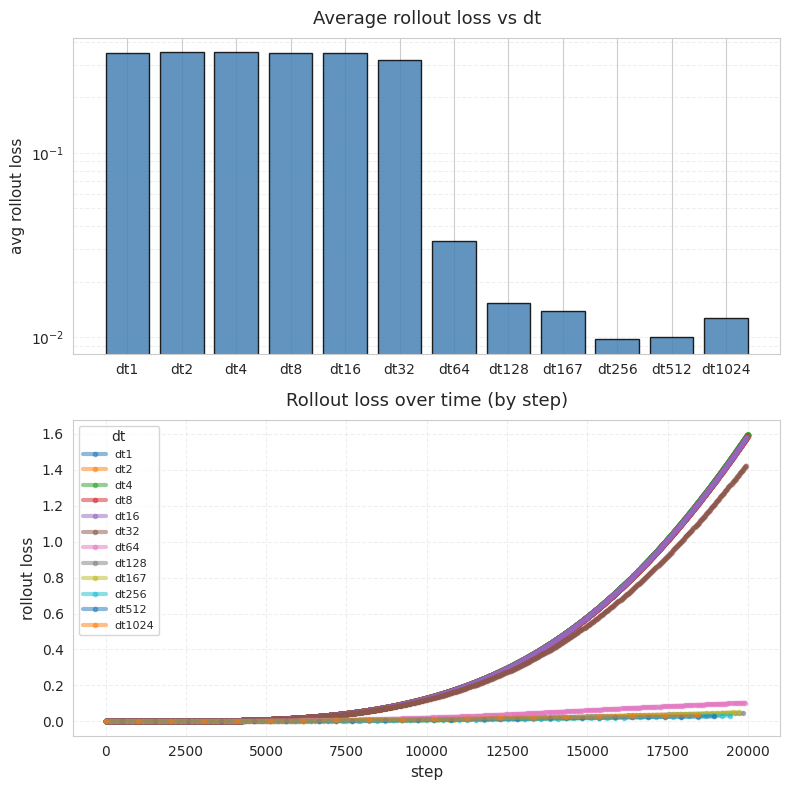

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

time_steps = data['time_step']        # e.g. ['dt8','dt4',...]
rollouts   = data['rollout_loss']     # list of list-of-(loss, step)

# --- sort dt's numerically ---
dt_num = [int(s.replace('dt', '')) for s in time_steps]
order = np.argsort(dt_num)

time_steps_sorted = [time_steps[i] for i in order]
rollouts_sorted   = [rollouts[i] for i in order]

# --- compute mean rollout loss for each dt (bar plot) ---
#   just average the loss component of each (loss, step) tuple
mean_rollout_loss = [
    np.mean([l for (l, s) in rollout])
    for rollout in rollouts_sorted
]

# --- create subplots ---
fig, (ax_mean, ax_time) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

# ---- 1) average rollout loss vs dt (bar) ----
ax_mean.bar(time_steps_sorted, mean_rollout_loss,
            color="steelblue", edgecolor="black", alpha=0.85)
ax_mean.set_yscale('log')
ax_mean.set_ylabel("avg rollout loss", fontsize=11)
ax_mean.set_title("Average rollout loss vs dt", fontsize=13, pad=10)
ax_mean.grid(True, which="both", axis="y", linestyle="--", alpha=0.3)
ax_mean.set_axisbelow(True)

# ---- 2) rollout loss vs step for every dt ----
for ts, rollout in zip(time_steps_sorted, rollouts_sorted):
    losses = [l for (l, s) in rollout]
    steps  = [s for (l, s) in rollout]
    ax_time.plot(steps, losses, marker='o', linewidth=3, label=ts, markersize=3, alpha=0.5)

# ax_time.set_yscale('log')       # remove this line if you want linear y
ax_time.set_xlabel("step", fontsize=11)
ax_time.set_ylabel("rollout loss", fontsize=11)
ax_time.set_title("Rollout loss over time (by step)", fontsize=13, pad=10)
ax_time.grid(True, which="both", linestyle="--", alpha=0.3)
ax_time.legend(title="dt", fontsize=8)

fig.tight_layout()
plt.show()

In [10]:
print(gt_pos.shape)
print(preds.shape)

torch.Size([20000, 8, 2])
torch.Size([78, 8, 2])


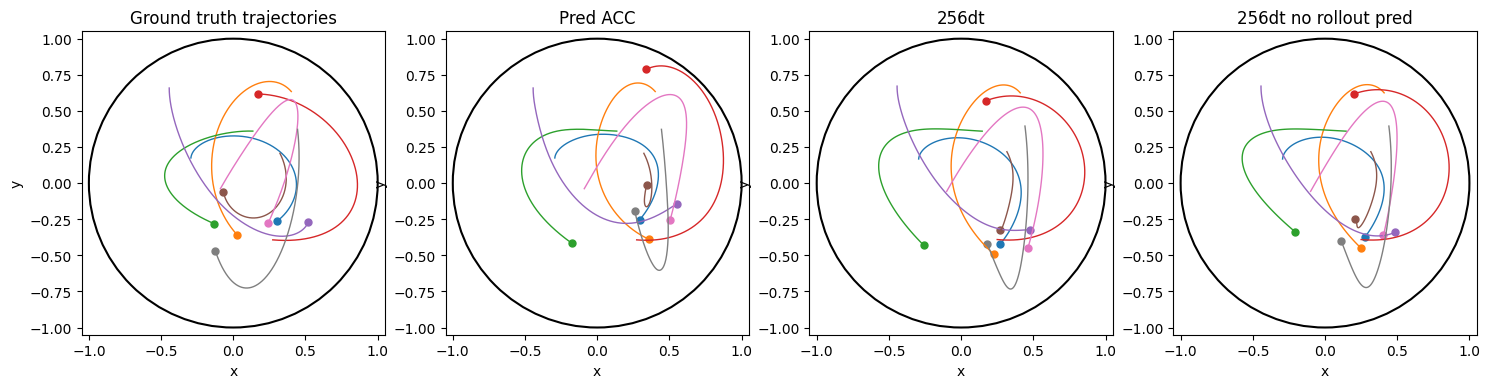

In [11]:
# get the predictions and the ground truth
# ground_truth = pkl.load(open('../data/spring_mass/static_graph/graphs/trial_0.pkl', 'rb'))

# split data up into train
config = yaml.safe_load(open('../results/SpringMass/GAT/model/pred_acc_no_edges_self_loops/trial_0_config.yaml', 'r'))
dat_train, dat_val, dat_test = utils.split_with_config(ground_truth, config)

fig, ax = plt.subplots(1, 4, figsize=(18, 6))

# plotting ground truth
gt_pos = torch.stack([i.pos for i in dat_test])
plot_trajectories(gt_pos.permute(2, 1, 0), ax=ax[0])
ax[0].set_title('Ground truth trajectories')

# Plotting predictions
preds = pkl.load(open('../results/SpringMass/GPS/smoothed/model/gt_edges_pred_acc_no_rollout_val_no_jerk/trial_0_rollout_preds.pkl', 'rb'))
preds = torch.stack(preds)
plot_trajectories(preds.permute(2, 1, 0), ax=ax[1])
ax[1].set_title(f"Pred ACC")

preds = pkl.load(open('../_dt_sweep_experiment/results/model/dt256/trial_0_rollout_preds.pkl', 'rb'))
preds = torch.stack(preds)
plot_trajectories(preds.permute(2, 1, 0), ax=ax[2])
ax[2].set_title(f"256dt")

preds = pkl.load(open('../results/SpringMass/GPS/smoothed/model/pred_pos_no_rollout_val/trial_0_rollout_preds.pkl', 'rb'))
preds = torch.stack(preds)
plot_trajectories(preds.permute(2, 1, 0), ax=ax[3])
ax[3].set_title(f"256dt no rollout pred")

plt.show()

In [10]:
# Plotting acceleration over time
ground_truth = pkl.load(open('../data/spring_mass/static_graph/graphs/trial_0.pkl', 'rb'))

In [ ]:
import numpy as np
acc_over_time = [np.linalg.norm(i.acc[0,:]) for i in ground_truth]
pos_over_time = [np.linalg.norm(i.pos[0,:]) for i in ground_truth]
plt.plot(range(len(acc_over_time)), acc_over_time)
plt.plot(range(len(pos_over_time)), pos_over_time)
plt.hlines(0.8, 0, len(pos_over_time), linestyle='--', color='k')
plt.xlim([0, 10000])
